In [1]:
import pandas as pd
sub = pd.read_csv("/kaggle/input/cafa-6-protein-function-prediction/sample_submission.tsv", sep= "\t", header = None,on_bad_lines="skip")
sub.columns = ["The Protein ID", "The Gene Ontology term (GO) ID", "Predicted link probability that GO appear in Protein"]
sub.head(5)

,The Protein ID,The Gene Ontology term (GO) ID,Predicted link probability that GO appear in Protein
0,A0A0C5B5G6,GO:0000001,0.123
1,A0A0C5B5G6,GO:0000002,0.456
2,A0A1B0GTW7,GO:0000001,0.123
3,A0A1B0GTW7,GO:0000002,0.456
4,A0JNW5,GO:0000001,0.123


In [2]:
MAIN_DIR = "/kaggle/input/cafa-6-protein-function-prediction"

import wandb
import os
import numpy as np
from tqdm import tqdm
import time
import matplotlib.pyplot as plt
plt.style.use('ggplot')

import torch
from torch.utils.data import Dataset
from torch import nn
from torch.utils.data import random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchmetrics.classification import MultilabelF1Score
from torchmetrics.classification import MultilabelAccuracy

import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import WandbLogger

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [3]:
class config:
    train_sequences_path = MAIN_DIR  + "/Train/train_sequences.fasta"
    train_labels_path = MAIN_DIR + "/Train/train_terms.tsv"
    test_sequences_path = MAIN_DIR + "/Test (Targets)/testsuperset.fasta"
    
    num_labels = 500
    n_epochs = 500
    batch_size = 50
    lr = 0.01
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

embeds_map = {
    "T5" : "t5embeds",
    "ProtBERT" : "cafa6-protbert-embeddings",
    "EMS2" : "cafa-6-ems-2-embeddings-numpy"
}

embeds_dim = {
    "T5" : 1024,
    "ProtBERT" : 1024,
    "EMS2" : 1280
}

In [4]:
class ProteinSequenceDataset(Dataset):
    
    def __init__(self, datatype, embeddings_source):
        super(ProteinSequenceDataset).__init__()
        self.datatype = datatype
        
        if embeddings_source in ["ProtBERT", "EMS2"]:
            embeds = np.load("/kaggle/input/"+embeds_map[embeddings_source]+"/"+datatype+"_embeddings.npy")
            ids = np.load("/kaggle/input/"+embeds_map[embeddings_source]+"/"+datatype+"_ids.npy")
        
        if embeddings_source == "T5":
            embeds = np.load("/kaggle/input/"+embeds_map[embeddings_source]+"/"+datatype+"_embeds.npy")
            ids = np.load("/kaggle/input/"+embeds_map[embeddings_source]+"/"+datatype+"_ids.npy")
            
        embeds_list = []
        for l in range(embeds.shape[0]):
            embeds_list.append(embeds[l,:])
        self.df = pd.DataFrame(data={"EntryID": ids, "embed" : embeds_list})
        
        if datatype=="train":
            np_labels = np.load(
                "/kaggle/input/cafa6top500"+ \
                "/train_targets_top"+str(config.num_labels)+".npy")
            df_labels = pd.DataFrame(self.df['EntryID'])
            df_labels['labels_vect']=[row for row in np_labels]
            self.df = self.df.merge(df_labels, on="EntryID")
            
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        embed = torch.tensor(self.df.iloc[index]["embed"] , dtype = torch.float32)
        if self.datatype=="train":
            targets = torch.tensor(self.df.iloc[index]["labels_vect"], dtype = torch.float32)
            return embed, targets
        if self.datatype=="test":
            id = self.df.iloc[index]["EntryID"]
            return embed, id
        

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Optional, Tuple
import math


class SEBlock(nn.Module):
    """Squeeze-and-Excitation block for channel-wise feature recalibration."""
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool1d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c = x.size()
        y = x.unsqueeze(2)
        y = self.squeeze(y).view(b, c)
        y = self.excitation(y)
        return x * y


class SwishGLU(nn.Module):
    """Gated Linear Unit with Swish activation (SwiGLU) - used in modern LLMs."""
    def __init__(self, dim_in: int, dim_out: int):
        super().__init__()
        self.linear_gate = nn.Linear(dim_in, dim_out)
        self.linear_value = nn.Linear(dim_in, dim_out)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gate = F.silu(self.linear_gate(x))
        value = self.linear_value(x)
        return gate * value


class MixerBlock(nn.Module):
    """MLP-Mixer style block - mixes features across different dimensions."""
    def __init__(self, dim: int, expansion_factor: int = 4):
        super().__init__()
        hidden_dim = dim * expansion_factor
        
        self.norm1 = nn.LayerNorm(dim)
        self.mlp1 = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(0.1)
        )
        
        self.norm2 = nn.LayerNorm(dim)
        self.mlp2 = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(0.1)
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.mlp1(self.norm1(x))
        x = x + self.mlp2(self.norm2(x))
        return x


class SpectralNorm(nn.Module):
    """Spectral Normalization wrapper for any linear layer."""
    def __init__(self, module: nn.Module, power_iterations: int = 1):
        super().__init__()
        self.module = nn.utils.spectral_norm(module, n_power_iterations=power_iterations)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.module(x)


class FeatureNormalization(nn.Module):
    """Multiple normalization options in one module."""
    def __init__(self, dim: int, norm_type: str = 'batch'):
        super().__init__()
        if norm_type == 'batch':
            self.norm = nn.BatchNorm1d(dim, track_running_stats=True)
        elif norm_type == 'layer':
            self.norm = nn.LayerNorm(dim)
        elif norm_type == 'instance':
            self.norm = nn.InstanceNorm1d(dim, track_running_stats=True)
        elif norm_type == 'group':
            num_groups = min(32, dim)
            self.norm = nn.GroupNorm(num_groups, dim)
        else:
            self.norm = nn.Identity()
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.norm(x)


class DropConnect(nn.Module):
    """DropConnect - drops entire connections rather than neurons."""
    def __init__(self, drop_prob: float = 0.1):
        super().__init__()
        self.drop_prob = drop_prob
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if not self.training or self.drop_prob == 0:
            return x
        keep_prob = 1 - self.drop_prob
        mask = torch.bernoulli(torch.full_like(x, keep_prob))
        return x * mask / keep_prob


class GatedResidual(nn.Module):
    """Gated residual connection - learns when to use residual."""
    def __init__(self, dim: int):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Sigmoid()
        )
    
    def forward(self, x: torch.Tensor, residual: torch.Tensor) -> torch.Tensor:
        gate = self.gate(x)
        return gate * x + (1 - gate) * residual


class NoiseInjection(nn.Module):
    """Adds learnable noise for regularization (used in StyleGAN)."""
    def __init__(self, channels: int):
        super().__init__()
        self.weight = nn.Parameter(torch.zeros(1, channels))
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.training:
            noise = torch.randn(x.size(0), 1, device=x.device)
            return x + self.weight * noise
        return x


class StochasticDepth(nn.Module):
    """Stochastic Depth for regularization - randomly drops residual branches during training."""
    def __init__(self, drop_prob: float = 0.1):
        super().__init__()
        self.drop_prob = drop_prob
    
    def forward(self, x: torch.Tensor, residual: torch.Tensor) -> torch.Tensor:
        if not self.training or self.drop_prob == 0:
            return x + residual
        
        keep_prob = 1 - self.drop_prob
        mask = torch.bernoulli(torch.full((x.size(0), 1), keep_prob, device=x.device))
        mask = mask.expand_as(residual)
        return x + residual * mask / keep_prob


class ResidualBlock(nn.Module):
    """
    Enhanced residual block with multiple optional enhancements.
    Supports SE blocks, different normalizations, GLU, and more.
    """
    def __init__(
        self, 
        in_dim: int, 
        out_dim: int, 
        dropout: float = 0.3, 
        stochastic_depth: float = 0.1,
        use_se_block: bool = False,
        use_swiglu: bool = False,
        use_spectral_norm: bool = False,
        use_noise_injection: bool = False,
        use_gated_residual: bool = False,
        use_dropconnect: bool = False,
        norm_type: str = 'batch'
    ):
        super().__init__()
        
        self.use_swiglu = use_swiglu
        self.use_gated_residual = use_gated_residual
        
        if use_swiglu:
            self.linear = SwishGLU(in_dim, out_dim)
        else:
            linear = nn.Linear(in_dim, out_dim)
            self.linear = SpectralNorm(linear) if use_spectral_norm else linear
        
        self.norm = FeatureNormalization(out_dim, norm_type)
        self.activation = nn.GELU() if not use_swiglu else nn.Identity()
        self.dropout = nn.Dropout(dropout)
        self.dropconnect = DropConnect(dropout * 0.5) if use_dropconnect else nn.Identity()
        self.se_block = SEBlock(out_dim) if use_se_block else nn.Identity()
        self.noise_injection = NoiseInjection(out_dim) if use_noise_injection else nn.Identity()
        self.projection = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()
        
        if use_gated_residual:
            self.residual = GatedResidual(out_dim)
        else:
            self.stochastic_depth = StochasticDepth(stochastic_depth)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = self.projection(x)
        
        out = self.linear(x)
        out = self.norm(out)
        out = self.activation(out)
        out = self.noise_injection(out)
        out = self.dropout(out)
        out = self.dropconnect(out)
        out = self.se_block(out)
        
        if self.use_gated_residual:
            out = self.residual(out, identity)
        else:
            out = self.stochastic_depth(identity, out)
        
        return out


class MultiTokenAttention(nn.Module):
    """Proper multi-head attention by splitting features into tokens."""
    def __init__(self, embed_dim: int, num_heads: int = 8, num_tokens: int = 4, dropout: float = 0.1):
        super().__init__()
        self.num_tokens = num_tokens
        self.token_dim = embed_dim // num_tokens
        
        assert embed_dim % num_tokens == 0, f"embed_dim {embed_dim} must be divisible by num_tokens {num_tokens}"
        
        self.attention = nn.MultiheadAttention(
            embed_dim=self.token_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.layer_norm = nn.LayerNorm(self.token_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.size(0)
        x_tokens = x.view(batch_size, self.num_tokens, self.token_dim)
        attn_output, _ = self.attention(x_tokens, x_tokens, x_tokens)
        x_tokens = self.layer_norm(x_tokens + self.dropout(attn_output))
        return x_tokens.view(batch_size, -1)


class ImprovedMultiLayerPerceptron(nn.Module):
    """
    State-of-the-art MLP with extensive enhancement options.
    """
    def __init__(
        self, 
        input_dim: int, 
        num_classes: int, 
        hidden_dims: list = [864, 512, 384],
        num_heads: int = 8,
        num_attention_tokens: int = 4,
        dropout_rates: list = [0.2, 0.3, 0.4],
        stochastic_depth_rate: float = 0.1,
        use_attention: bool = True,
        use_mixer: bool = False,
        use_se_block: bool = True,
        use_swiglu: bool = False,
        use_spectral_norm: bool = False,
        use_noise_injection: bool = False,
        use_gated_residual: bool = False,
        use_dropconnect: bool = False,
        norm_type: str = 'batch',
        label_smoothing: float = 0.1,
        use_input_layer_norm: bool = False,
        input_dropout: float = 0.1
    ):
        super().__init__()
        
        assert len(hidden_dims) == len(dropout_rates), "hidden_dims and dropout_rates must have same length"
        
        self.use_attention = use_attention
        self.use_mixer = use_mixer
        self.label_smoothing = label_smoothing
        self.gradient_norms = []
        
        self.input_norm = nn.LayerNorm(input_dim) if use_input_layer_norm else nn.Identity()
        self.input_dropout = nn.Dropout(input_dropout)
        
        self.input_block = ResidualBlock(
            input_dim, 
            hidden_dims[0], 
            dropout=dropout_rates[0],
            stochastic_depth=stochastic_depth_rate,
            use_se_block=use_se_block,
            use_swiglu=use_swiglu,
            use_spectral_norm=use_spectral_norm,
            use_noise_injection=use_noise_injection,
            use_gated_residual=use_gated_residual,
            use_dropconnect=use_dropconnect,
            norm_type=norm_type
        )
        
        self.hidden_blocks = nn.ModuleList([
            ResidualBlock(
                hidden_dims[i], 
                hidden_dims[i+1], 
                dropout=dropout_rates[i+1],
                stochastic_depth=stochastic_depth_rate * (i + 2) / len(hidden_dims),
                use_se_block=use_se_block,
                use_swiglu=use_swiglu,
                use_spectral_norm=use_spectral_norm,
                use_noise_injection=use_noise_injection,
                use_gated_residual=use_gated_residual,
                use_dropconnect=use_dropconnect,
                norm_type=norm_type
            )
            for i in range(len(hidden_dims) - 1)
        ])
        
        if self.use_mixer:
            self.mixer_blocks = nn.ModuleList([
                MixerBlock(dim=hidden_dims[-1], expansion_factor=4)
                for _ in range(2)
            ])
        
        if self.use_attention:
            attention_dim = hidden_dims[-1]
            if attention_dim % num_attention_tokens != 0:
                attention_dim = (attention_dim // num_attention_tokens) * num_attention_tokens
                self.attention_projection = nn.Linear(hidden_dims[-1], attention_dim)
                self.attention_projection_back = nn.Linear(attention_dim, hidden_dims[-1])
            else:
                self.attention_projection = nn.Identity()
                self.attention_projection_back = nn.Identity()
                
            self.attention = MultiTokenAttention(
                embed_dim=attention_dim,
                num_heads=num_heads,
                num_tokens=num_attention_tokens,
                dropout=0.1
            )
        
        self.pre_output_norm = nn.LayerNorm(hidden_dims[-1])
        output_layer = nn.Linear(hidden_dims[-1], num_classes)
        self.output = SpectralNorm(output_layer) if use_spectral_norm else output_layer
        
        self._init_weights()
        
    def _init_weights(self):
        """Proper weight initialization for better training."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.BatchNorm1d, nn.LayerNorm, nn.GroupNorm)):
                if hasattr(m, 'weight') and m.weight is not None:
                    nn.init.constant_(m.weight, 1)
                if hasattr(m, 'bias') and m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.input_norm(x)
        x = self.input_dropout(x)
        x = self.input_block(x)
        
        for block in self.hidden_blocks:
            x = block(x)
        
        if self.use_mixer:
            for mixer in self.mixer_blocks:
                x = mixer(x)
        
        if self.use_attention:
            x_proj = self.attention_projection(x)
            x_attn = self.attention(x_proj)
            x = self.attention_projection_back(x_attn)
        
        x = self.pre_output_norm(x)
        x = self.output(x)
        return x
    
    def get_loss(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """Calculate loss with optional label smoothing."""
        if self.label_smoothing > 0 and self.training:
            return F.cross_entropy(logits, targets, label_smoothing=self.label_smoothing)
        return F.cross_entropy(logits, targets)
    
    def clip_gradients(self, max_norm: float = 1.0) -> float:
        """Clip gradients and track gradient norm."""
        total_norm = torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm)
        self.gradient_norms.append(total_norm.item())
        return total_norm.item()
    
    def get_gradient_stats(self) -> dict:
        """Get statistics about gradient norms."""
        if not self.gradient_norms:
            return {}
        return {
            'mean': sum(self.gradient_norms) / len(self.gradient_norms),
            'max': max(self.gradient_norms),
            'min': min(self.gradient_norms),
            'recent': self.gradient_norms[-10:] if len(self.gradient_norms) >= 10 else self.gradient_norms
        }
    
    def reset_gradient_stats(self):
        """Reset gradient norm tracking."""
        self.gradient_norms = []

In [6]:
def train_model(embeddings_source, model_type="linear", train_size=0.9):
    
    train_dataset = ProteinSequenceDataset(datatype="train", embeddings_source=embeddings_source)
    
    train_set, val_set = random_split(
        train_dataset, 
        lengths=[int(len(train_dataset)*train_size), 
                len(train_dataset)-int(len(train_dataset)*train_size)],
        generator=torch.Generator().manual_seed(42)  
    )
    
    train_dataloader = torch.utils.data.DataLoader(
        train_set, batch_size=config.batch_size, shuffle=True, 
        num_workers=4, pin_memory=True  
    )
    val_dataloader = torch.utils.data.DataLoader(
        val_set, batch_size=config.batch_size, shuffle=False, 
        num_workers=4, pin_memory=True
    )
    
    if model_type == "linear":
        model = nn.DataParallel(ImprovedMultiLayerPerceptron(
                                                            input_dim=embeds_dim[embeddings_source],
                                                            num_classes=config.num_labels,
                                                            hidden_dims=[864, 512, 384],
                                                            num_heads=8,
                                                            num_attention_tokens=4,
                                                            dropout_rates=[0.2, 0.3, 0.4],
                                                            stochastic_depth_rate=0.15,
                                                            use_attention=True,
                                                            use_mixer=True,
                                                            use_se_block=True,
                                                            use_swiglu=True,
                                                            use_spectral_norm=True,
                                                            use_noise_injection=True,
                                                            use_gated_residual=True,
                                                            use_dropconnect=True,
                                                            norm_type='layer',
                                                            label_smoothing=0.1,
                                                            use_input_layer_norm=True,
                                                            input_dropout=0.1
                                                        )).to(config.device)
    else:
        raise ValueError(f"Unknown model_type: {model_type}. Choose 'linear' or 'convolutional'")
        
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=2, verbose=True)
    criterion = torch.nn.CrossEntropyLoss()
    f1_score = MultilabelF1Score(num_labels=config.num_labels).to(config.device)
    
    n_epochs = config.n_epochs
    print("BEGIN TRAINING...")
    
    train_loss_history = []
    val_loss_history = []
    train_f1score_history = []
    val_f1score_history = []
    
    best_val_score = 0.0
    best_model_state = None
    patience_counter = 0
    early_stopping_patience = 5
    
    for epoch in range(n_epochs):
        print(f"EPOCH {epoch+1}/{n_epochs}")
        
        ## TRAIN PHASE
        model.train()
        train_losses = []
        train_scores = []
        
        for embed, targets in tqdm(train_dataloader, desc="Training"):
            embed = embed.to(config.device, non_blocking=True)
            targets = targets.to(config.device, non_blocking=True)
            
            optimizer.zero_grad()
            preds = model(embed)
            loss = criterion(preds, targets)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) 
            optimizer.step()
            
            train_losses.append(loss.item())
            
            with torch.no_grad():
                score = f1_score(preds, targets)
                train_scores.append(score.item())
        
        avg_train_loss = np.mean(train_losses)
        avg_train_score = np.mean(train_scores)
        print(f"Train Loss: {avg_train_loss:.4f} | Train F1-Score: {avg_train_score:.4f}")
        train_loss_history.append(avg_train_loss)
        train_f1score_history.append(avg_train_score)
        
        ## VALIDATION PHASE
        model.eval()
        val_losses = []
        val_scores = []
        
        with torch.no_grad(): 
            for embed, targets in tqdm(val_dataloader, desc="Validation"):
                embed = embed.to(config.device, non_blocking=True)
                targets = targets.to(config.device, non_blocking=True)
                
                preds = model(embed)
                loss = criterion(preds, targets)
                score = f1_score(preds, targets)
                
                val_losses.append(loss.item())
                val_scores.append(score.item())
        
        avg_val_loss = np.mean(val_losses)
        avg_val_score = np.mean(val_scores)
        print(f"Val Loss: {avg_val_loss:.4f} | Val F1-Score: {avg_val_score:.4f}")
        val_loss_history.append(avg_val_loss)
        val_f1score_history.append(avg_val_score)
        
        if avg_val_score > best_val_score:
            best_val_score = avg_val_score
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"✓ New best model saved (F1: {best_val_score:.4f})")
        else:
            patience_counter += 1
        
        scheduler.step(avg_val_loss)
        
        if patience_counter >= early_stopping_patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break
        
        print()
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Restored best model with validation F1-Score: {best_val_score:.4f}")
    
    print("TRAINING FINISHED")
    print(f"Final Training F1-Score: {train_f1score_history[-1]:.4f}")
    print(f"Best Validation F1-Score: {best_val_score:.4f}")
    
    history = {
        "train_loss": train_loss_history,
        "val_loss": val_loss_history,
        "train_f1": train_f1score_history,
        "val_f1": val_f1score_history
    }
    
    return model, val_loss_history, val_f1score_history

In [7]:
protbert_model, protbert_losses, protbert_scores = train_model(embeddings_source = "ProtBERT",
                                                               model_type = "linear")

BEGIN TRAINING...
EPOCH 1/500


Training: 100%|██████████| 1484/1484 [00:57<00:00, 25.61it/s]


Train Loss: 16.4002 | Train F1-Score: 0.0072


Validation: 100%|██████████| 165/165 [00:02<00:00, 55.16it/s]


Val Loss: 16.2842 | Val F1-Score: 0.0073
✓ New best model saved (F1: 0.0073)

EPOCH 2/500


...

Val Loss: 16.2603 | Val F1-Score: 0.0073

EPOCH 9/500


Training: 100%|██████████| 1484/1484 [00:56<00:00, 26.45it/s]


Train Loss: 16.3372 | Train F1-Score: 0.0075


Validation: 100%|██████████| 165/165 [00:03<00:00, 53.46it/s]

Val Loss: 16.2578 | Val F1-Score: 0.0074
Early stopping triggered after 9 epochs
Restored best model with validation F1-Score: 0.0076
TRAINING FINISHED
Final Training F1-Score: 0.0075
Best Validation F1-Score: 0.0076


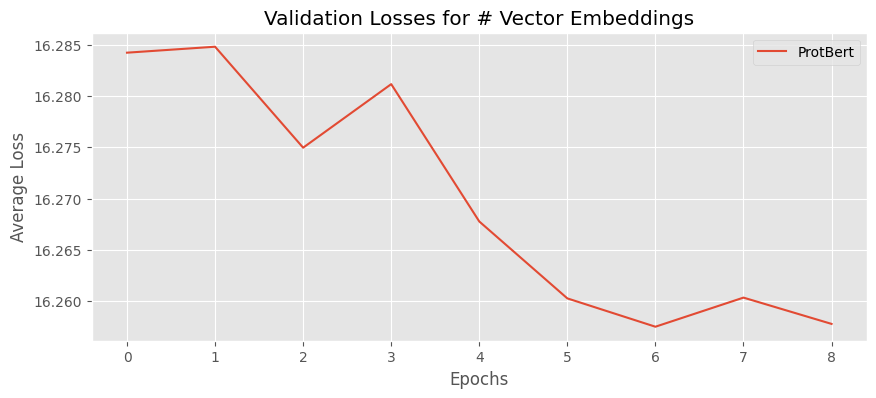

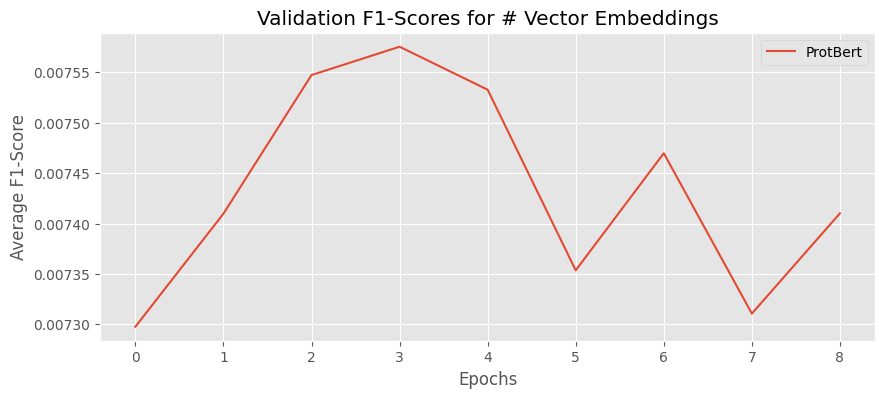

In [8]:
plt.figure(figsize = (10, 4))
plt.plot(protbert_losses, label = "ProtBert") 
plt.title("Validation Losses for # Vector Embeddings")
plt.xlabel("Epochs")
plt.ylabel("Average Loss")
plt.legend()
plt.show()

plt.figure(figsize = (10, 4))
plt.plot(protbert_scores, label = "ProtBert")
plt.title("Validation F1-Scores for # Vector Embeddings")
plt.xlabel("Epochs")
plt.ylabel("Average F1-Score")
plt.legend()
plt.show()

## PREDICTION

In [9]:
def predict(embeddings_source):
    
    test_dataset = ProteinSequenceDataset(datatype="test", embeddings_source = embeddings_source)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)
    
    if embeddings_source == "T5":
        model = t5_model
    if embeddings_source == "ProtBERT":
        model = protbert_model
    if embeddings_source == "EMS2":
        model = ems2_model
        
    model.eval()
    
    labels = pd.read_csv(config.train_labels_path, sep = "\t")
    top_terms = labels.groupby("term")["EntryID"].count().sort_values(ascending=False)
    labels_names = top_terms[:config.num_labels].index.values
    print("GENERATE PREDICTION FOR TEST SET...")

    ids_ = np.empty(shape=(len(test_dataloader)*config.num_labels,), dtype=object)
    go_terms_ = np.empty(shape=(len(test_dataloader)*config.num_labels,), dtype=object)
    confs_ = np.empty(shape=(len(test_dataloader)*config.num_labels,), dtype=np.float32)

    for i, (embed, id) in tqdm(enumerate(test_dataloader)):
        embed = embed.to(config.device)
        confs_[i*config.num_labels:(i+1)*config.num_labels] = torch.nn.functional.sigmoid(model(embed)).squeeze().detach().cpu().numpy()
        ids_[i*config.num_labels:(i+1)*config.num_labels] = id[0]
        go_terms_[i*config.num_labels:(i+1)*config.num_labels] = labels_names

    submission_df = pd.DataFrame(data={"Id" : ids_, "GO term" : go_terms_, "Confidence" : confs_})
    print("PREDICTIONS DONE")
    return submission_df

In [10]:
submission_df = predict("ProtBERT")

GENERATE PREDICTION FOR TEST SET...


224309it [28:14, 132.34it/s]


PREDICTIONS DONE


In [11]:
len(submission_df)

112154500

In [12]:
submission_df.to_csv('submission.tsv', sep='\t', header=False, index=False)